In [1]:
import numpy as np

In [2]:
import pandas as pd

In [5]:
df=pd.read_csv("Crop_recommendation.csv")

In [7]:
df.describe ()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [6]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

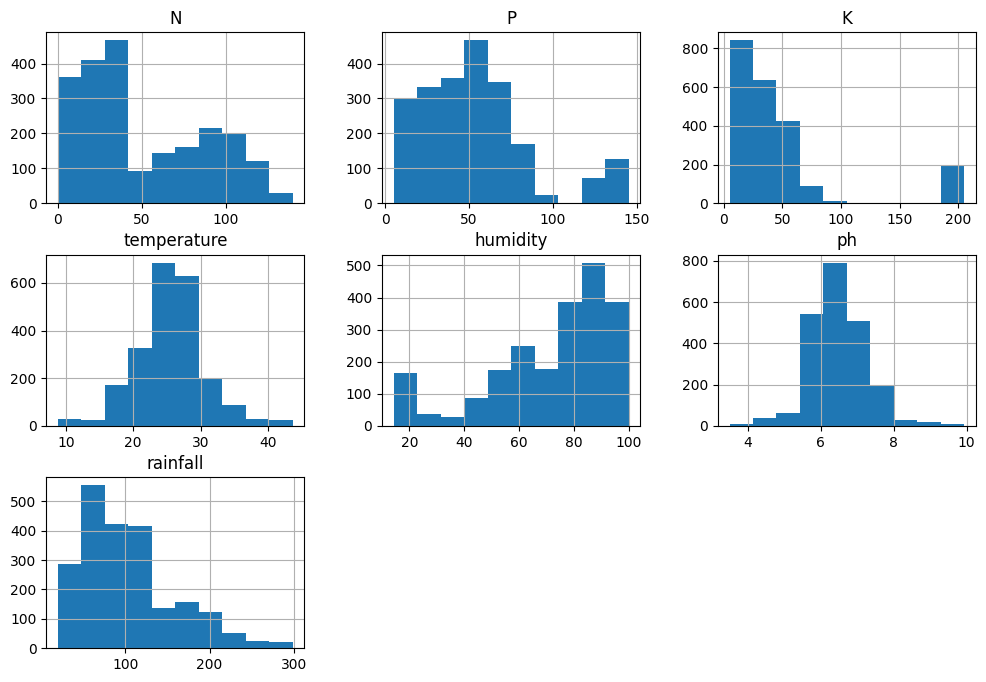

In [8]:
df.hist(figsize=(12,8))
plt.show()

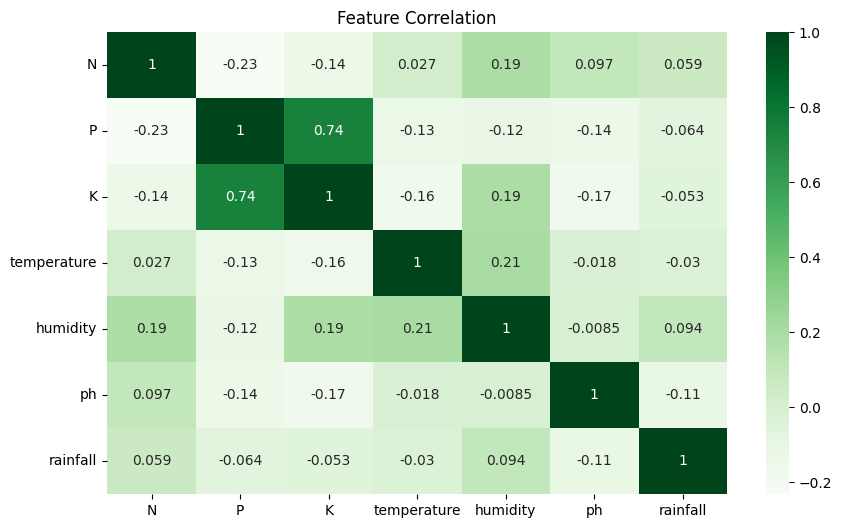

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='Greens')
plt.title("Feature Correlation")
plt.show()

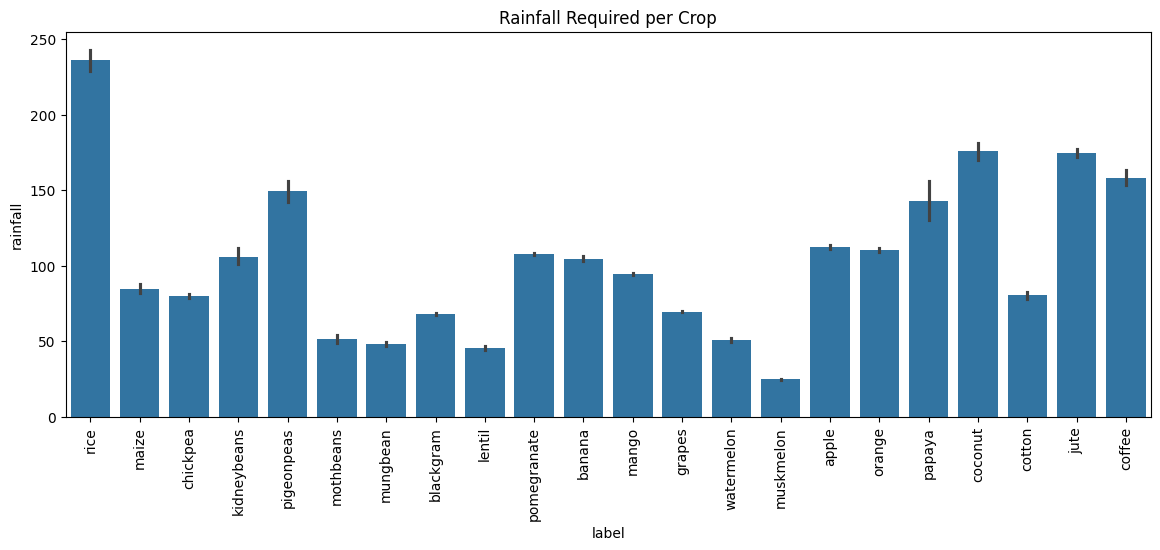

In [11]:
plt.figure(figsize=(14,5))
sns.barplot(x='label', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.title("Rainfall Required per Crop")
plt.show()

In [12]:
X = df.drop('label', axis=1)   # input columns
y = df['label']                 # output column

print(X.shape)
print(y.shape)

(2200, 7)
(2200,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 7)
Testing data: (440, 7)


In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [15]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9931818181818182


<Figure size 1400x1000 with 0 Axes>

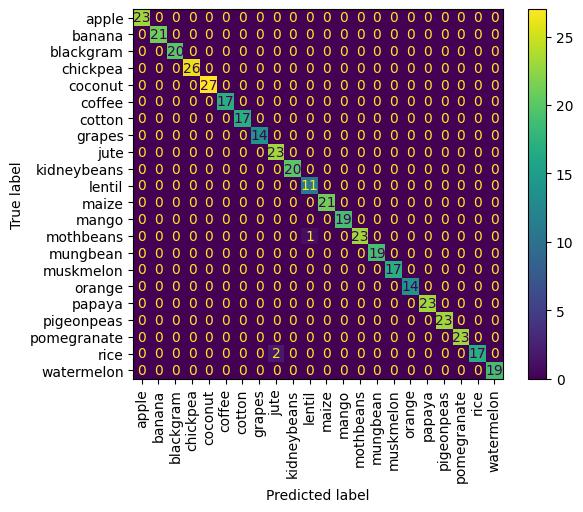

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

plt.figure(figsize=(14,10))   # ← moved here separately
disp.plot(xticks_rotation=90)  # ← removed figsize from here
plt.show()

In [18]:
import pickle

with open('crop_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved! ✅")

Model saved! ✅


In [19]:
from google.colab import files
files.download('crop_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>